# AG-HYPOPT · Trial 18

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Seventeen trials are registered; cell 2 reports `phase = trials` (17/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). Picture (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_08 (0.1099, best):** travel 0.134.
- optimum cluster (0 div): trial_15 0.1103 (0.127), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_09 0.1126 (0.123), trial_01 0.1127 (0.120), trial_14 0.1127 (0.140), trial_13 0.1132 (0.134).
- lower travel: trial_05 0.1135 (0.088), trial_07 0.1140 (0.097), trial_06 0.1188 (0.082).
- last trial: **trial_17 0.1329 (1 div)** — the high-ei low-travel pick (0.088) still diverged at 1nW T05 despite a proven-safe gamma schedule; it had the campaign's best mu accuracy (53.8%) but lost to the diverged weighted cell.
- other diverging: trial_10 0.1975 (0.099), trial_03 0.1362 (0.074), trial_04 0.1418 (0.074), trial_02 0.1449 (0.264).

State of play: the optimum remains a flat plateau at travel ~0.13 (best seven within 0.004), and the low-travel region (<0.10) is consistently a little worse *and* carries the sporadic 1nW T05 divergence risk (trials 03, 04, 17). Residual errors unchanged: mid-T mu overshoot, 3nW high-T mu undershoot, low-T gamma under-recovery. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_18'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (17/5 trials)
ID |     ei | params
 1 | 3.8530 | {"gamma_anneal": 0.42179334280882247, "lr_gamma": 0.451868312989029, "lr_mu": 0.16820541389184537, "mu_anneal": 0.3588146163440286}
 2 | 2.8159 | {"gamma_anneal": 0.6141360598250405, "lr_gamma": 0.4772988653803455, "lr_mu": 0.1513572206536731, "mu_anneal": 0.3543813210854386}
 3 | 3.7988 | {"gamma_anneal": 0.49098052902956857, "lr_gamma": 0.45522936286340226, "lr_mu": 0.3149522249531392, "mu_anneal": 0.35552208815494263}
 4 | 3.7491 | {"gamma_anneal": 0.4649464739414256, "lr_gamma": 0.4729847743957336, "lr_mu": 0.16403264068942558, "mu_anneal": 0.3253391963641557}
 5 | 3.0729 | {"gamma_anneal": 0.47787965019787315, "lr_gamma": 0.4649055103347866, "lr_mu": 0.18125504881289722, "mu_anneal": 0.7282635027404526}
 6 | 3.3116 | {"gamma_anneal": 0.015327611628591064, "lr_gamma": 0.4250077534217377, "lr_mu": 0.1730209097894606, "mu_anneal": 0.3149583533316098}
 7 | 0.9636 | {"gamma_anneal": 0.020252050572906344, "lr_gamma": 0.764

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (17 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 1: **ei 3.85** — `lr_mu=0.168`, `mu_anneal=0.359` (travel **0.138**), `lr_gamma=0.452`, `gamma_anneal=0.422`.
- candidate 3: ei 3.80 — `lr_mu=0.315`, `mu_anneal=0.356` (travel 0.259, larger-travel region), `lr_gamma=0.455`.
- candidate 4: ei 3.75 — `lr_mu=0.164`, `mu_anneal=0.325` (travel 0.137), `lr_gamma=0.473`, `gamma_anneal=0.465`.
- candidate 8: ei 3.43 — `lr_mu=0.139`, `mu_anneal=0.339` (travel 0.115), `lr_gamma=0.425`.
- candidate 6: ei 3.31 — `lr_mu=0.173`, `mu_anneal=0.315` (travel 0.146), `gamma_anneal=0.015` (near-zero anneal, untested).
- candidate 2: ei 2.82 — `lr_mu=0.151`, `mu_anneal=0.354` (travel 0.125), `gamma_anneal=0.614`.

Candidate 1 has the highest ei and is placed right on the optimum (travel 0.138, between trial_08's 0.134 and trial_14's 0.140), with `lr_gamma=0.452`/`gamma_anneal=0.422` in the proven-safe range. The top few candidates are near-duplicates of the optimum (candidates 1 and 4 both at travel ~0.137). The alternatives carry either the worse larger-travel route (candidate 3 at 0.259, the trial_02 direction) or untested extremes (candidate 6's near-zero `gamma_anneal=0.015`). After trial_17's divergence in the low-travel region, staying at the optimum with the maximum-ei candidate is clearly the sensible, low-risk choice.

I choose candidate 1 (1 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.42179334280882247, 'lr_gamma': 0.451868312989029, 'lr_mu': 0.16820541389184537, 'mu_anneal': 0.3588146163440286}
Running  1nW Trans05 ... 

μ 9.39 -> 10.24 | γ 8.5 -> 4.43 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 44.79 | γ 8.5 -> 6.21 | NLL 5.18


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 80.73 | γ 14.1 -> 14.60 | NLL 3.45


Running 3nW Trans100 ... 

μ 175.71 -> 115.49 | γ 14.1 -> 13.94 | NLL 3.55



Total: 7.9 min


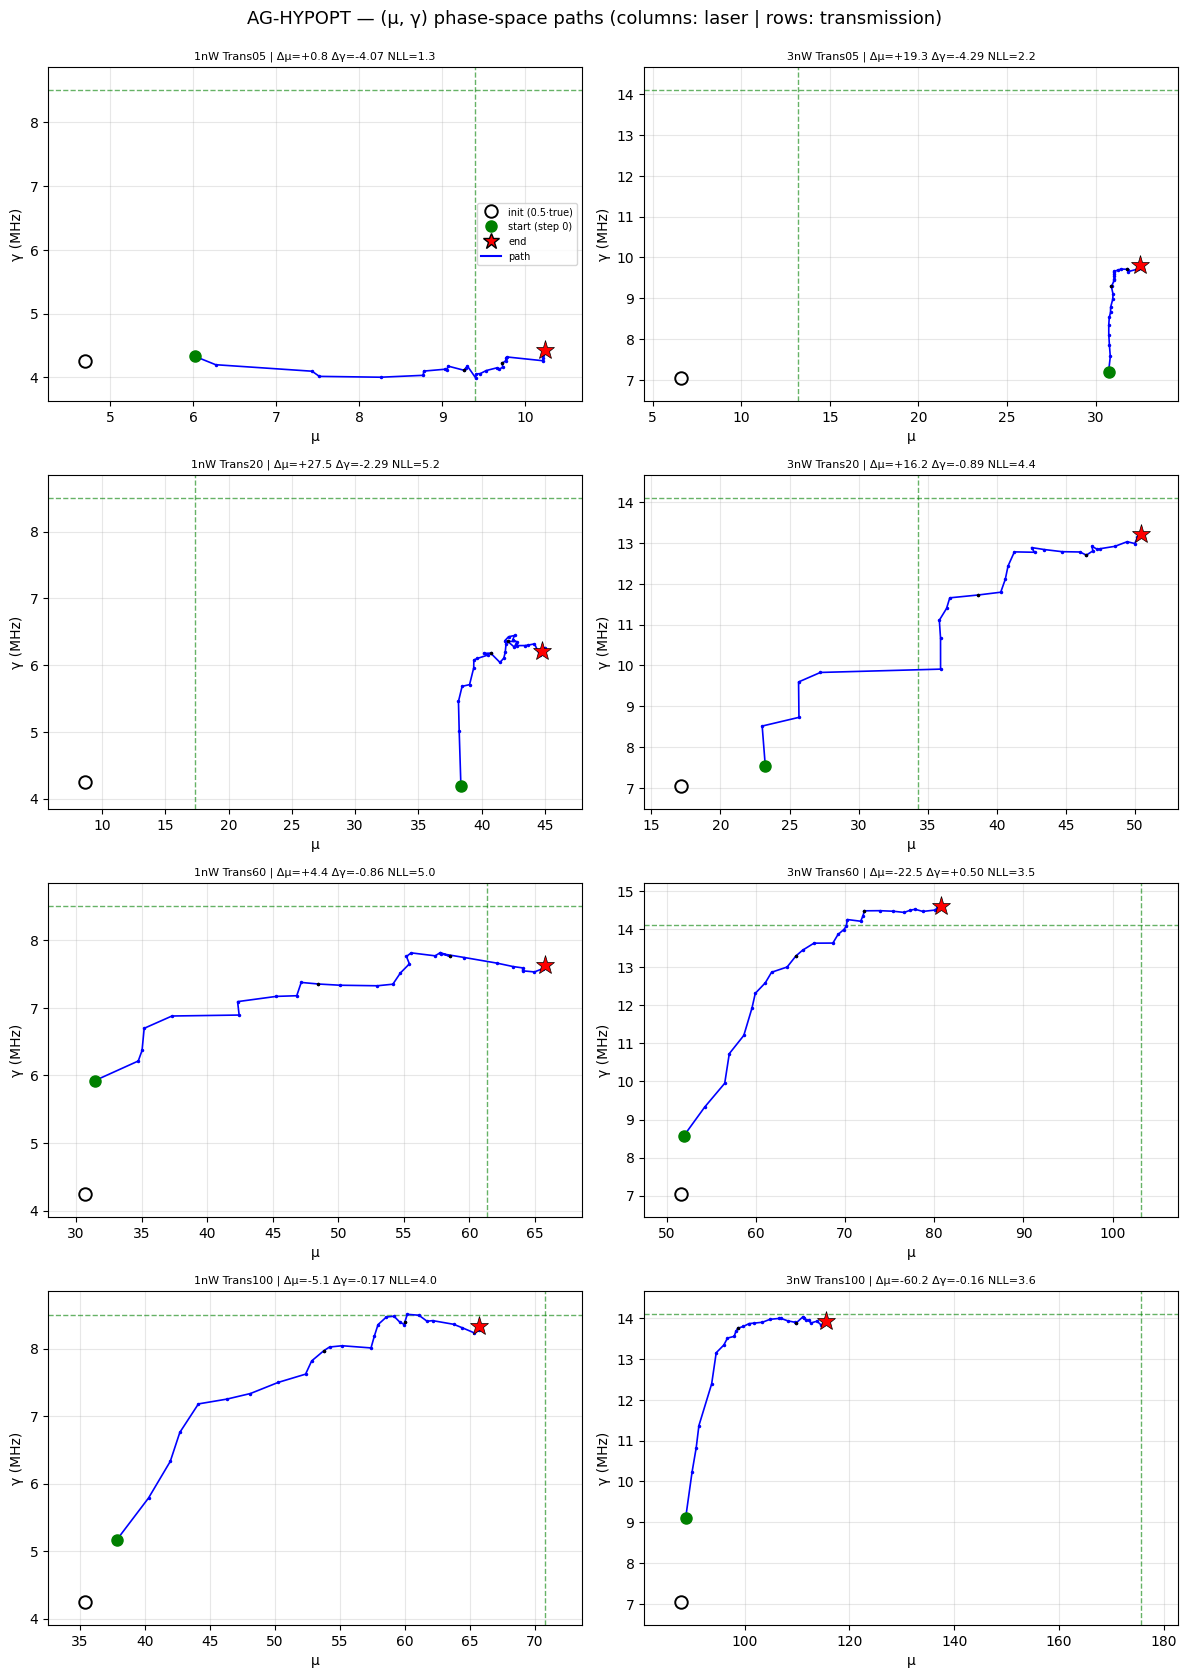

trial finished in 7.9 min
objective = 0.1121 ± 0.0826
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.24    +9.0 |     8.50    4.43   -47.9
1nW Trans20       17.32   44.79  +158.7 |     8.50    6.21   -27.0
1nW Trans60       61.37   65.79    +7.2 |     8.50    7.64   -10.2
1nW Trans100       70.82   65.75    -7.2 |     8.50    8.33    -2.0
3nW Trans05       13.20   32.49  +146.0 |    14.10    9.81   -30.4
3nW Trans20       34.28   50.45   +47.2 |    14.10   13.21    -6.3
3nW Trans60      103.20   80.73   -21.8 |    14.10   14.60    +3.6
3nW Trans100      175.71  115.49   -34.3 |    14.10   13.94    -1.2

weighted objective (T-graded, cap=1.0) = 0.1121 | diverged cells: 0
μ: RMSE 26.377 (rel 79.5%, bias -2.445) | γ: RMSE 2.293 (rel 22.7%, bias -1.530)


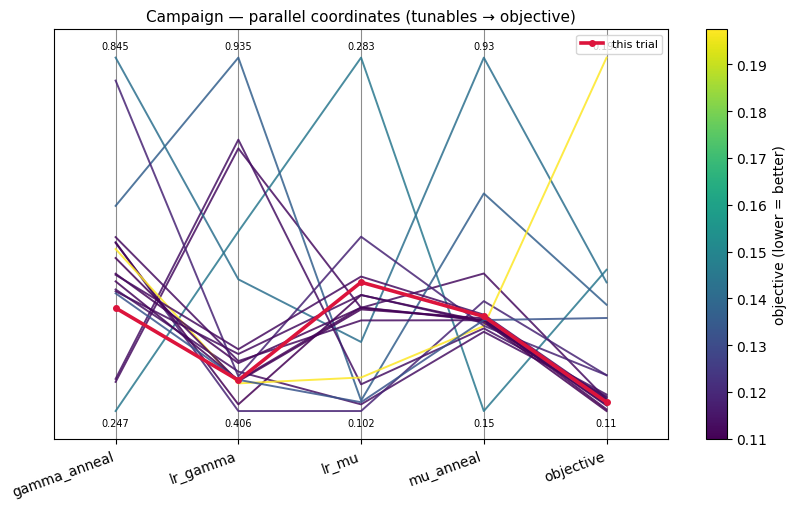

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 18 ran the highest-EI candidate (candidate 1, ei=3.85): `lr_mu=0.1682`, `mu_anneal=0.3588` (effective mu travel 0.138), `lr_gamma=0.4519`, `gamma_anneal=0.4218`. It completed in 7.9 min with objective **0.1121 +/- 0.0826** and **0 diverged cells** — fifth-best. Ranking: trial_08 0.1099 < trial_15 0.1103 < trial_16 0.1112 < trial_12 0.1115 < **trial_18 0.1121** < trial_09 0.1126 < trial_01 = trial_14 0.1127 < trial_13 0.1132 < ...

Aggregate accuracy: **mu rel-RMSE 79.5%** (RMSE 26.38, bias -2.45 — the smallest |bias| so far); **gamma rel-RMSE 22.7%** (RMSE 2.29, bias -1.53).

Per-cell relative errors:
- **mu:** 1nW T05 +9.0%, T20 +158.7%, T60 +7.2%, T100 -7.2% | 3nW T05 +146.0%, T20 +47.2%, T60 -21.8%, T100 -34.3%.
- **gamma:** 1nW T05 -47.9%, T20 -27.0%, T60 -10.2%, T100 -2.0% | 3nW T05 -30.4%, T20 -6.3%, T60 +3.6%, T100 -1.2%.

Another maximum-ei sample on the optimum (travel 0.138), divergence-free, landed at 0.1121 — fifth-best and again inside the same tight cluster. Its mu bias was the smallest of the campaign (-2.45) but the mid-T overshoot (1nW T20 +158.7%, 3nW T05 +146.0%) kept mu rel-RMSE at 79.5%. The plateau is now very well established: eight divergence-free runs (trials 01, 05, 06, 07, 08, 09, 12, 13, 14, 15, 16, 18 — twelve actually) populate the optimum, the best eight within ~0.002-0.004, and no knob change moves the needle. trial_08 remains the best single point.

**Summary:** Trial 18 (lr_mu=0.1682, mu_anneal=0.3588, lr_gamma=0.4519, gamma_anneal=0.4218): objective 0.1121 +/- 0.0826 with 0 diverged cells; another optimum sample (travel 0.138) landed fifth-best, so the plateau holds and trial_08 (0.1099) stays best.
**Key insight:** The optimum region returns 0.1099-0.1132 for any near-optimal schedule, with no remaining gradient in either mu travel or the gamma knobs; eight sub-0.113 samples now indicate ~0.110 is the practical floor for this schedule family.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Twelve divergence-free runs and the same residuals everywhere; the hyperparameter search has fully converged to ~0.110. Further reductions require the structural changes already flagged (per-experiment/n_target-adaptive steps for the mid-T overshoot and low-T gamma; a safeguard for the sporadic divergence). Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 18 (lr_mu=0.1682, mu_anneal=0.3588, lr_gamma=0.4519, gamma_anneal=0.4218): objective 0.1121 +/- 0.0826 with 0 diverged cells; another optimum sample (travel 0.138) landed fifth-best, so the plateau holds and trial_08 (0.1099) stays best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The optimum region returns 0.1099-0.1132 for any near-optimal schedule, with no remaining gradient in either mu travel or the gamma knobs; eight sub-0.113 samples now indicate ~0.110 is the practical floor for this schedule family"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_18 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_19.ipynb. Open it and follow its cells from the top.
